In [ ]:
from google.colab import files
uploaded = files.upload()

Saving rrc00_codered_anomalous_features.csv to rrc00_codered_anomalous_features.csv
Saving rrc00_codered_normal_features.csv to rrc00_codered_normal_features.csv
Saving rrc00_moscow_blackout_anomalous_features.csv to rrc00_moscow_blackout_anomalous_features.csv
Saving rrc00_moscow_blackout_normal_features.csv to rrc00_moscow_blackout_normal_features.csv
Saving rrc00_nimda_anomalous_features.csv to rrc00_nimda_anomalous_features.csv
Saving rrc00_nimda_normal_features.csv to rrc00_nimda_normal_features.csv
Saving rrc00_slammer_anomalous_features.csv to rrc00_slammer_anomalous_features.csv
Saving rrc00_slammer_normal_features.csv to rrc00_slammer_normal_features.csv
Saving rrc00_tmnet_anomalous_features.csv to rrc00_tmnet_anomalous_features.csv
Saving rrc00_tmnet_normal_features.csv to rrc00_tmnet_normal_features.csv
Saving rrc04_codered_anomalous_features.csv to rrc04_codered_anomalous_features.csv
Saving rrc04_codered_normal_features.csv to rrc04_codered_normal_features.csv
Saving rrc04

In [ ]:
!pip install xgboost seaborn

In [ ]:
import pandas as pd
import glob

files = glob.glob("*.csv")

dfs = []
for f in files:
    df = pd.read_csv(f)
    dfs.append(df)

df = pd.concat(dfs, ignore_index=True)

print("Total rows:", len(df))
df.head()

Total rows: 17515


,Unnamed: 0,num_announcements,num_withdrawals,avg_as_path_length,max_as_path_length,std_as_path_length,duplicate_withdrawals,unique_withdrawn_prefixes,total_records,collector,event,label_str,label
0,2005-05-25 04:00:00+00:00,2030,511,5.997537,22.0,2.471412,114,132,2541,rrc00,moscow,blackout_anomalous,1
1,2005-05-25 04:03:00+00:00,1740,365,5.006322,16.0,2.482459,97,140,2105,rrc00,moscow,blackout_anomalous,1
2,2005-05-25 04:06:00+00:00,1866,202,4.493569,16.0,1.417700,45,79,2068,rrc00,moscow,blackout_anomalous,1
3,2005-05-25 04:09:00+00:00,1208,177,5.071192,15.0,1.779640,44,51,1385,rrc00,moscow,blackout_anomalous,1
4,2005-05-25 04:12:00+00:00,1487,212,4.810356,15.0,2.069167,46,70,1699,rrc00,moscow,blackout_anomalous,1


In [ ]:
import numpy as np

# Ratio
df["ann_wit_ratio"] = df["num_announcements"] / (df["num_withdrawals"] + 1)

# Differences
df["ann_diff"] = df["num_announcements"].diff().fillna(0)
df["wit_diff"] = df["num_withdrawals"].diff().fillna(0)

# Rolling stats
df["ann_roll_mean"] = df["num_announcements"].rolling(3).mean().fillna(0)
df["wit_roll_mean"] = df["num_withdrawals"].rolling(3).mean().fillna(0)

df["ann_roll_std"] = df["num_announcements"].rolling(3).std().fillna(0)
df["wit_roll_std"] = df["num_withdrawals"].rolling(3).std().fillna(0)

df.head()

,Unnamed: 0,num_announcements,num_withdrawals,avg_as_path_length,max_as_path_length,std_as_path_length,duplicate_withdrawals,unique_withdrawn_prefixes,total_records,collector,event,label_str,label,ann_wit_ratio,ann_diff,wit_diff,ann_roll_mean,wit_roll_mean,ann_roll_std,wit_roll_std
0,2005-05-25 04:00:00+00:00,2030,511,5.997537,22.0,2.471412,114,132,2541,rrc00,moscow,blackout_anomalous,1,3.964844,0.0,0.0,0.000000,0.000000,0.000000,0.000000
1,2005-05-25 04:03:00+00:00,1740,365,5.006322,16.0,2.482459,97,140,2105,rrc00,moscow,blackout_anomalous,1,4.754098,-290.0,-146.0,0.000000,0.000000,0.000000,0.000000
2,2005-05-25 04:06:00+00:00,1866,202,4.493569,16.0,1.417700,45,79,2068,rrc00,moscow,blackout_anomalous,1,9.192118,126.0,-163.0,1878.666667,359.333333,145.414351,154.577920
3,2005-05-25 04:09:00+00:00,1208,177,5.071192,15.0,1.779640,44,51,1385,rrc00,moscow,blackout_anomalous,1,6.786517,-658.0,-25.0,1604.666667,248.000000,349.252535,102.093095
4,2005-05-25 04:12:00+00:00,1487,212,4.810356,15.0,2.069167,46,70,1699,rrc00,moscow,blackout_anomalous,1,6.981221,279.0,35.0,1520.333333,197.000000,330.264036,18.027756


In [ ]:
df["occurrence_label"] = (df["label_str"] == "anomalous").astype(int)

In [ ]:
from sklearn.metrics import f1_score, precision_score

def compute_mad(series):
    m = series.median()
    mad = (series - m).abs().median()
    return m, max(mad, 1e-9)

def apply_mad(series, m, mad, n):
    return (series - m).abs() > (n * mad)

def persistence(series):
    return (
        series.astype(int)
        .rolling(2)
        .sum()
        .ge(2)
        .astype(int)
    )

def mad_per_event(df):
    results = []

    for event in df["event"].unique():
        sub = df[df["event"] == event].copy()

        baseline = sub[sub["occurrence_label"] == 0]

        m1, mad1 = compute_mad(baseline["num_announcements"])
        m2, mad2 = compute_mad(baseline["num_withdrawals"])

        best_n = 1
        best_score = -1

        for n in np.linspace(1, 5, 50):
            a = apply_mad(sub["num_announcements"], m1, mad1, n)
            w = apply_mad(sub["num_withdrawals"], m2, mad2, n)

            pred = persistence(a & w)

            if len(set(pred)) < 2:
                continue

            f1 = f1_score(sub["occurrence_label"], pred)
            prec = precision_score(sub["occurrence_label"], pred)

            score = 0.6 * f1 + 0.4 * prec

            if score > best_score:
                best_score = score
                best_n = n

        # final labels
        a = apply_mad(sub["num_announcements"], m1, mad1, best_n)
        w = apply_mad(sub["num_withdrawals"], m2, mad2, best_n)

        sub["mad_label"] = persistence(a & w)
        sub["optimal_n"] = best_n

        print(f"{event}: n={best_n:.2f}, F1={best_score:.3f}")

        results.append(sub)

    return pd.concat(results)

df = mad_per_event(df)

moscow: n=1.00, F1=0.000
codered: n=5.00, F1=0.336
nimda: n=2.96, F1=0.772
tmnet: n=2.47, F1=0.856
slammer: n=1.16, F1=0.885


In [ ]:
FEATURES = [
    "num_announcements",
    "num_withdrawals",
    "avg_as_path_length",
    "max_as_path_length",
    "std_as_path_length",
    "duplicate_withdrawals",
    "unique_withdrawn_prefixes",
    "total_records",
    "ann_wit_ratio",
    "ann_diff",
    "wit_diff",
    "ann_roll_mean",
    "wit_roll_mean",
    "ann_roll_std",
    "wit_roll_std"
]

df_model = df[FEATURES + ["mad_label"]].dropna()

In [ ]:
from sklearn.model_selection import train_test_split

X = df_model[FEATURES]
y = df_model["mad_label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

In [ ]:
from sklearn.utils import resample

train_df = X_train.copy()
train_df["label"] = y_train

maj = train_df[train_df["label"] == 0]
minr = train_df[train_df["label"] == 1]

min_up = resample(minr, replace=True, n_samples=len(maj), random_state=42)

train_bal = pd.concat([maj, min_up]).sample(frac=1, random_state=42)

X_train = train_bal[FEATURES]
y_train = train_bal["label"]

print("Balanced:", y_train.value_counts())

Balanced: label
1    12729
0    12729
Name: count, dtype: int64


In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=400,
    max_depth=15,
    min_samples_split=5,
    class_weight="balanced",
    n_jobs=-1,
    random_state=42
)

rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

In [ ]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=400,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

xgb.fit(X_train, y_train)
xgb_pred = xgb.predict(X_test)

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def eval_model(name, y_true, y_pred):
    print(f"\n{name}")
    print("Accuracy :", accuracy_score(y_true, y_pred))
    print("Precision:", precision_score(y_true, y_pred))
    print("Recall   :", recall_score(y_true, y_pred))
    print("F1 Score :", f1_score(y_true, y_pred))

eval_model("Random Forest", y_test, rf_pred)
eval_model("XGBoost", y_test, xgb_pred)


Random Forest
Accuracy : 0.9683128746788467
Precision: 0.8125
Recall   : 0.8504672897196262
F1 Score : 0.8310502283105022

XGBoost
Accuracy : 0.9723094490436769
Precision: 0.827485380116959
Recall   : 0.881619937694704
F1 Score : 0.8536953242835595


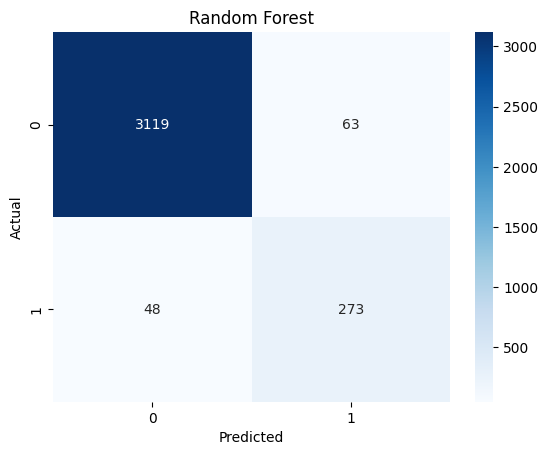

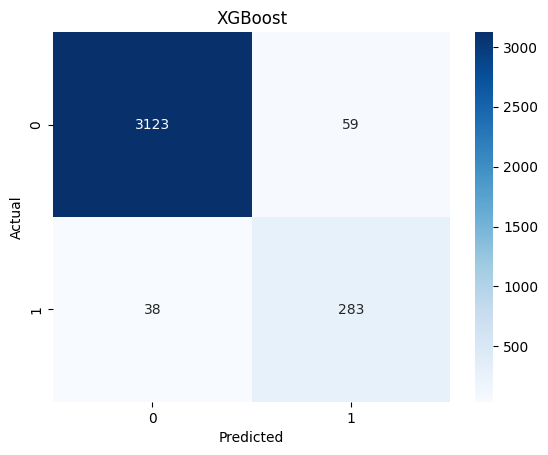

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

def plot_cm(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

plot_cm(y_test, rf_pred, "Random Forest")
plot_cm(y_test, xgb_pred, "XGBoost")